In [8]:
import pandas as pd
import numpy as np 

In [9]:
df = pd.read_csv("powerplant_data.csv")

In [10]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [11]:
#AT => Temperature
# V => Vaccum
#AP => Pressure
#Rh => humidity

#PE => produced energy

In [12]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [13]:
X = df.drop("PE",axis = 1)
y = df["PE"]

In [14]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [15]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

# convert dataset into Tensors

In [16]:
# split out data
from sklearn.model_selection import train_test_split

In [17]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state = 42
)

In [18]:
X_test

,AT,V,AP,RH
2513,29.70,57.35,1005.63,57.35
9411,25.71,71.64,1008.85,77.31
8745,17.83,44.92,1025.04,70.58
9085,9.46,41.40,1026.78,87.58
4950,29.90,64.79,1016.90,48.24
...,...,...,...,...
7204,20.46,51.43,1010.06,83.79
1599,29.70,67.17,1007.31,66.56
5697,14.64,39.58,1011.46,71.90
350,29.47,71.32,1008.07,67.00


In [19]:
df.shape

(9568, 5)

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()
X_train_Scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [23]:
%pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [24]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [25]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

2.12.1+cpu
False


In [26]:
import torch.nn as nn

In [34]:
X_train_tensor = torch.tensor(X_train_Scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1,1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)

In [30]:
type(X_train_Scaled)

numpy.ndarray

In [31]:
type(y_train)

pandas.core.series.Series

In [33]:
y_train

5487    442.75
3522    432.52
6916    428.80
7544    426.07
7600    436.58
         ...  
5734    436.44
5191    441.20
5390    464.26
860     440.45
7270    484.44
Name: PE, Length: 7654, dtype: float64

In [35]:
y_test_tensor

tensor([[433.2700],
        [438.1600],
        [458.4200],
        ...,
        [467.8000],
        [437.1400],
        [456.7800]])

# DataSet AND DataLoader

In [37]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_train_tensor,y_train_tensor)

In [39]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = True)

# HOW TO BUILD ANN MODEL 

In [44]:
import torch.nn as nn

class ANN(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            nn.Linear(6, 6),
            nn.ReLU(),

            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

In [47]:
import torch.optim as optim

model = ANN()

#loss, optiizer
criteria = nn.MSELoss()
optimizer = optim.Adam(model.parameters())


# Training ANN

In [76]:
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100
for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 eopch

    for xb,yb in train_loader:
        # xb = features of 1 batch
        #yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb)# forward  pro.... predicted output for this batch 
        loss=criteria(outputs,yb) # compute loss
        loss.backward() # back prop ...compute gradients
        optimizer.step() # params update
        running_loss +=loss.item() #loss is a tensort => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    #validation
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = criteria(outputs,yb)
            running_val_loss +=loss
    
    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch ${epoch+1}/{epochs} ==> train loss = ${epoch_train_loss} 7 val loss = ${epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch $1/100 ==> train loss = $18.806185201803842 7 val loss = $19.05754280090332
epoch $2/100 ==> train loss = $18.80306874513626 7 val loss = $18.852140426635742
epoch $3/100 ==> train loss = $18.850436850388846 7 val loss = $18.682085037231445
epoch $4/100 ==> train loss = $18.883851885795593 7 val loss = $18.666748046875
epoch $5/100 ==> train loss = $18.878502436478932 7 val loss = $18.729290008544922
epoch $6/100 ==> train loss = $18.836883558829626 7 val loss = $18.776573181152344
epoch $7/100 ==> train loss = $18.863204403718314 7 val loss = $18.75306510925293
epoch $8/100 ==> train loss = $18.86265418926875 7 val loss = $19.01437759399414
epoch $9/100 ==> train loss = $18.802378396193188 7 val loss = $18.656034469604492
epoch $10/100 ==> train loss = $18.86048597494761 7 val loss = $18.762422561645508
epoch $11/100 ==> train loss = $18.82638860344887 7 val loss = $18.72492218017578
epoch $12/100 ==> train loss = $18.83247628211975 7 val loss = $18.93987274169922
epoch $13/100 

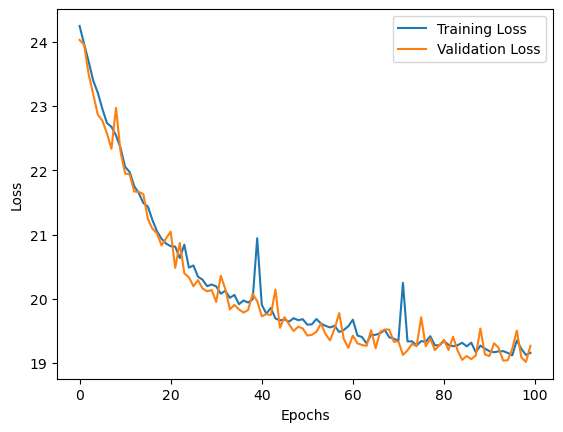

In [71]:
import matplotlib.pyplot as plt
loss_df =pd.DataFrame({
    "Training_loss": train_losses,
    "Validation_loss": val_losses
})

plt.plot(loss_df["Training_loss"],label = "Training Loss")
plt.plot(loss_df["Validation_loss"],label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

In [75]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

# EVALUATE

In [77]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criteria(train_preds, y_train_tensor)
    test_mse_loss = criteria(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 18.693872451782227
Testing MSE: 17.106876373291016


In [79]:
from sklearn.metrics import r2_score
print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9402158834991008


In [80]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,436.862061,433.27
1,436.387695,438.16
2,458.742554,458.42
3,476.001587,480.82
4,438.218964,441.41
...,...,...
1909,450.508087,456.70
1910,434.070648,438.04
1911,467.923065,467.80
1912,433.238800,437.14
